# 🧠 Entrenando tu primer LLM desde cero

En este notebook vas a construir y entrenar un **modelo de lenguaje** (**LLM**) desde cero, línea por línea, sin cajas negras.

No usaremos modelos pre-entrenados — vamos a construir la arquitectura nosotros mismos con **PyTorch** y entrenarla en un texto simple.

### ¿Qué vamos a construir?

Un **mini-GPT**: un modelo Transformer decoder-only que aprende a predecir el siguiente carácter dado un contexto.  
Es la misma arquitectura que GPT-2/3/4, sólo que mucho más pequeña.

### ¿Qué aprenderás?

| Sección | Concepto |
|---|---|
| 1 | Instalación de dependencias (Mac / Linux / Windows) |
| 2 | Tokenización a nivel de carácter |
| 3 | Preparación del dataset con ventana deslizante |
| 4 | Embeddings de tokens y posición |
| 5 | Self-Attention y Multi-Head Attention |
| 6 | Bloque Transformer completo |
| 7 | Modelo GPT-like ensamblado |
| 8 | Loop de entrenamiento con AdamW |
| 9 | Gráfica de la pérdida |
| 10 | Generación de texto (inferencia) |
| 11 | Perplexity como métrica de calidad |
| 12 | Experimentos para mejorar el modelo |

.
> **Prerequisito:** Python 3.9+. No se necesita GPU — el modelo es tan pequeño que corre en CPU en minutos.

---
## 1. Instalación de dependencias

Solo necesitamos **PyTorch** y **Matplotlib**. No hay más deps.

---

### 🍎 Mac con Apple Silicon (M1 / M2 / M3 / M4)

PyTorch soporta natively Metal Performance Shaders (MPS) en Apple Silicon:

```bash
pip install torch torchvision torchaudio matplotlib
```

> La aceleración MPS se activa automáticamente con `device = "mps"` — lo verás más adelante.

---

### 🍎 Mac con Intel

```bash
pip install torch torchvision torchaudio matplotlib
```

> No hay aceleración de GPU disponible en Mac Intel. Usará CPU.

---

### 🐧 Linux (CPU)

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
pip install matplotlib
```

### 🐧 Linux (GPU NVIDIA — CUDA 12.1)

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
pip install matplotlib
```

---

### 🪟 Windows (CPU)

```powershell
pip install torch torchvision torchaudio matplotlib
```

### 🪟 Windows (GPU NVIDIA — CUDA 12.1)

```powershell
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
pip install matplotlib
```

### 🪟 Windows con Conda (recomendado en Windows)

```powershell
conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia
conda install matplotlib
```

---

> 📌 Verificá siempre la versión correcta de CUDA para tu GPU en [pytorch.org/get-started](https://pytorch.org/get-started/locally/)

In [2]:
#import subprocess, sys

# Instala las dependencias mínimas requeridas para este notebook
#subprocess.run(
#    [sys.executable, "-m", "pip", "install", "torch", "matplotlib", "--quiet"],
#    check=True
#)
#print("✅ Instalación completada")

---
## 2. Verificar instalación y detectar dispositivo

Primero verificamos que PyTorch esté instalado y detectamos qué acelerador de hardware tenemos disponible:

| Dispositivo | Significado |
|---|---|
| `cpu` | Solo procesador — funciona siempre, más lento |
| `mps` | Apple Silicon GPU via Metal — Mac M1/M2/M3/M4 |
| `cuda` | GPU NVIDIA — el más rápido para deep learning |

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math, time, random

print(f"✅ PyTorch versión : {torch.__version__}")
print()

# Detectar el mejor dispositivo disponible
if torch.cuda.is_available():
    device = torch.device("cuda")
    nombre_gpu = torch.cuda.get_device_name(0)
    memoria_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🟢 NVIDIA GPU disponible: {nombre_gpu} ({memoria_gb:.1f} GB VRAM)")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🟢 Apple Silicon GPU (Metal MPS) disponible")
else:
    device = torch.device("cpu")
    print("🔵 Usando CPU (sin GPU disponible)")

print(f"\n📍 Dispositivo seleccionado: {device}")
print("   Este notebook corre bien en CPU — el modelo es pequeño a propósito.")

✅ PyTorch versión : 2.11.0

🟢 Apple Silicon GPU (Metal MPS) disponible

📍 Dispositivo seleccionado: mps
   Este notebook corre bien en CPU — el modelo es pequeño a propósito.


---
## 3. El dataset: ¿qué texto va a aprender el modelo?

Para que el entrenamiento sea rápido y comprensible, usaremos un texto corto directamente en el código.  
El modelo aprenderá a **reproducir y continuar** el estilo de ese texto.

### ¿Por qué un texto corto?

- Un texto de ~2000 caracteres tarda segundos en entrenar (no horas)
- Podés ver el resultado inmediatamente
- Los conceptos son 100% iguales que con datasets de millones de tokens

### ¿Qué texto usamos?

Usamos un texto sobre inteligencia artificial. El modelo aprenderá a generar texto similar.  
Podés reemplazar `TEXTO` con cualquier contenido que quieras (un libro, código, letras de canciones).

> 💡 **Regla práctica:** Para que un modelo character-level aprenda algo útil,  
> necesitás al menos 100x más caracteres que parámetros del modelo.

In [4]:
# El texto que el modelo aprenderá a imitar
# Puedes reemplazarlo con cualquier texto (más texto = mejor resultado)
TEXTO = """
La inteligencia artificial es una rama de la informática que busca crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana. Entre estas tareas se incluyen el reconocimiento de voz, la comprensión del lenguaje natural, el aprendizaje y la resolución de problemas.

El aprendizaje automático es un subconjunto de la inteligencia artificial que permite a los sistemas aprender y mejorar a partir de la experiencia sin ser programados explícitamente. El aprendizaje automático se centra en el desarrollo de programas que pueden acceder a datos y utilizarlos para aprender por sí mismos.

El aprendizaje profundo es un método de aprendizaje automático que enseña a las computadoras a hacer lo que naturalmente hace el ser humano: aprender con el ejemplo. El aprendizaje profundo es una técnica clave detrás de los autos sin conductor, que permite al automóvil reconocer una señal de pare o distinguir a un peatón de una farola.

Las redes neuronales artificiales están inspiradas en el cerebro humano. Estas redes aprenden de grandes cantidades de datos. Al igual que los humanos aprenden de la experiencia, el algoritmo de la red neuronal aprende a realizar tareas de clasificación directamente de imágenes, texto o sonido.

Los transformers revolucionaron el procesamiento del lenguaje natural. Su mecanismo de atención permite al modelo enfocarse en partes relevantes de la entrada al generar cada parte de la salida. Esta arquitectura es la base de modelos como GPT, BERT y LLaMA.

Entrenar un modelo de lenguaje consiste en presentarle millones de ejemplos de texto y ajustar sus parámetros para que sea capaz de predecir el siguiente token. Con suficientes datos y capacidad, el modelo aprende gramática, hechos, razonamiento y hasta creatividad.
"""

print(f"📄 Texto cargado:")
print(f"   Total de caracteres : {len(TEXTO):,}")
print(f"   Total de palabras   : {len(TEXTO.split()):,}")
print(f"\nPrimeros 200 caracteres:")
print(f"{'─'*50}")
print(TEXTO[:200])

📄 Texto cargado:
   Total de caracteres : 1,781
   Total de palabras   : 275

Primeros 200 caracteres:
──────────────────────────────────────────────────

La inteligencia artificial es una rama de la informática que busca crear sistemas capaces de realizar tareas que normalmente requieren inteligencia humana. Entre estas tareas se incluyen el reconocim


---
## 4. Tokenización: de texto a números

Los modelos no entienden caracteres ni palabras — solo **números**.  
La **tokenización** es el proceso de convertir texto en una secuencia de enteros.

### Tipos de tokenización

| Tipo | Unidad | Vocabulario | Ejemplo |
|---|---|---|---|
| **Character-level** | 1 carácter | ~100 tokens | `h`, `o`, `l`, `a` |
| **Word-level** | 1 palabra | ~50,000 tokens | `hola`, `mundo` |
| **BPE (subword)** | fragmentos | ~32,000-100,000 | `hol`, `##a` |
| **SentencePiece** | subpalabras | variable | `▁hola`, `▁mundo` |

GPT-4 usa BPE con ~100,000 tokens. Nosotros usaremos **character-level** por ser el más simple de entender.

### El vocabulario

Es el conjunto de todos los tokens únicos que puede manejar el modelo.  
Con character-level tokenization, el vocabulario son **todos los caracteres únicos** del texto.

```
texto  →  "hola"  →  encode  →  [7, 14, 11, 0]  →  el modelo
el modelo  →  [7, 14, 11, 0]  →  decode  →  "hola"
```

In [5]:
# ─── Construir el vocabulario ─────────────────────────────────────────────────

# El vocabulario son todos los caracteres únicos del texto, ordenados
vocabulario = sorted(set(TEXTO))
vocab_size   = len(vocabulario)

print(f"📚 Vocabulario construido:")
print(f"   Tamaño: {vocab_size} caracteres únicos")
print(f"   Caracteres: {''.join(vocabulario[:30])} ...")
print()

# ─── Crear las funciones de encode y decode ───────────────────────────────────

# char → int  (cada carácter mapea a un índice)
char_a_int = {char: idx for idx, char in enumerate(vocabulario)}

# int → char  (cada índice mapea a un carácter)
int_a_char = {idx: char for idx, char in enumerate(vocabulario)}

def encode(texto: str) -> list[int]:
    """Convierte un string en una lista de enteros."""
    return [char_a_int[c] for c in texto]

def decode(tokens: list[int]) -> str:
    """Convierte una lista de enteros en un string."""
    return "".join(int_a_char[i] for i in tokens)

# ─── Demostración ─────────────────────────────────────────────────────────────
texto_ejemplo  = "hola mundo"
tokens_ejemplo = encode(texto_ejemplo)
texto_recup    = decode(tokens_ejemplo)

print(f"🔤 Ejemplo de tokenización:")
print(f"   Original  : '{texto_ejemplo}'")
print(f"   Tokens    : {tokens_ejemplo}")
print(f"   Recuperado: '{texto_recup}'")
print(f"   ¿Igual?   : {texto_ejemplo == texto_recup}")

# ─── Codificar el texto completo ──────────────────────────────────────────────
datos = torch.tensor(encode(TEXTO), dtype=torch.long)

print(f"\n📊 Dataset codificado:")
print(f"   Shape  : {datos.shape}")
print(f"   Dtype  : {datos.dtype}")
print(f"   Primeros 20 tokens: {datos[:20].tolist()}")

📚 Vocabulario construido:
   Tamaño: 46 caracteres únicos
   Caracteres: 
 ,.:ABCEGLMPRSTabcdefghijklmn ...

🔤 Ejemplo de tokenización:
   Original  : 'hola mundo'
   Tokens    : [23, 30, 27, 16, 1, 28, 36, 29, 19, 30]
   Recuperado: 'hola mundo'
   ¿Igual?   : True

📊 Dataset codificado:
   Shape  : torch.Size([1781])
   Dtype  : torch.int64
   Primeros 20 tokens: [0, 10, 16, 1, 24, 29, 35, 20, 27, 24, 22, 20, 29, 18, 24, 16, 1, 16, 33, 35]


---
## 5. Preparar los datos: ventana deslizante

El modelo aprende a **predecir el siguiente token** dado un contexto.  
Para esto, dividimos el texto en pares **(entrada X, objetivo Y)** usando una **ventana deslizante**.

### ¿Cómo funciona?

Supongamos que el texto codificado es: `[5, 3, 8, 1, 6, 2]` y el tamaño de contexto es 4.

```
X (entrada)         →   Y (lo que debe predecir)
─────────────────────────────────────────────────
[5]                 →   3
[5, 3]              →   8
[5, 3, 8]           →   1
[5, 3, 8, 1]        →   6     ← ventana completa
[3, 8, 1, 6]        →   2     ← la ventana desliza
```

En la práctica, esto se implementa extrayendo bloques de longitud `contexto + 1`:  
`X = bloque[:-1]` (todos menos el último) y `Y = bloque[1:]` (todos menos el primero).

### División train/validation

Separamos el 10% del texto como **conjunto de validación** para medir si el modelo está aprendiendo  
o memorizando (overfitting).

In [6]:
# ─── Hiperparámetros del dataset ──────────────────────────────────────────────
CONTEXTO   = 64   # cuántos tokens mira el modelo como "contexto" (tamaño de la ventana)
BATCH_SIZE = 32   # cuántos ejemplos se procesan en paralelo por paso
SPLIT      = 0.9  # 90% para entrenamiento, 10% para validación

# ─── División train / validación ─────────────────────────────────────────────
n_train = int(len(datos) * SPLIT)
datos_train = datos[:n_train]
datos_val   = datos[n_train:]

print(f"📦 División del dataset:")
print(f"   Total de tokens        : {len(datos):,}")
print(f"   Tokens de entrenamiento: {len(datos_train):,} ({SPLIT*100:.0f}%)")
print(f"   Tokens de validación   : {len(datos_val):,} ({(1-SPLIT)*100:.0f}%)")
print()

# ─── Función para obtener batches aleatorios ──────────────────────────────────
def get_batch(split: str):
    """
    Genera un mini-batch de pares (X, Y) aleatorios del dataset.
    
    Parameters:
        split: 'train' o 'val'
    
    Returns:
        x: tensor de shape (BATCH_SIZE, CONTEXTO) — las entradas
        y: tensor de shape (BATCH_SIZE, CONTEXTO) — los objetivos (x desplazado 1)
    """
    data = datos_train if split == 'train' else datos_val
    
    # Elegir BATCH_SIZE posiciones de inicio aleatorias
    # (cada posición debe tener suficiente texto por delante)
    indices = torch.randint(len(data) - CONTEXTO, (BATCH_SIZE,))

    # Para cada índice, extraer una ventana de CONTEXTO tokens
    x = torch.stack([data[i : i + CONTEXTO]     for i in indices])
    y = torch.stack([data[i + 1 : i + CONTEXTO + 1] for i in indices])  # desplazado 1
    
    return x.to(device), y.to(device)

# ─── Demostración de un batch ────────────────────────────────────────────────
x_demo, y_demo = get_batch('train')

print(f"🎲 Ejemplo de batch:")
print(f"   X shape: {x_demo.shape}  — ({BATCH_SIZE} ejemplos, {CONTEXTO} tokens cada uno)")
print(f"   Y shape: {y_demo.shape}  — (el objetivo: X desplazado 1)")
print()
print(f"Primer ejemplo del batch:")
print(f"   X[0] = {x_demo[0, :10].tolist()} ... (primeros 10 tokens)")
print(f"   Y[0] = {y_demo[0, :10].tolist()} ... (los mismos, desplazados 1)")
print()
print(f"Primer ejemplo decodificado:")
print(f"   X[0] → '{decode(x_demo[0].tolist())[:50]}'")

📦 División del dataset:
   Total de tokens        : 1,781
   Tokens de entrenamiento: 1,602 (90%)
   Tokens de validación   : 179 (10%)

🎲 Ejemplo de batch:
   X shape: torch.Size([32, 64])  — (32 ejemplos, 64 tokens cada uno)
   Y shape: torch.Size([32, 64])  — (el objetivo: X desplazado 1)

Primer ejemplo del batch:
   X[0] = [29, 22, 36, 16, 25, 20, 1, 29, 16, 35] ... (primeros 10 tokens)
   Y[0] = [22, 36, 16, 25, 20, 1, 29, 16, 35, 36] ... (los mismos, desplazados 1)

Primer ejemplo decodificado:
   X[0] → 'nguaje natural, el aprendizaje y la resolución de '


---
## 6. La arquitectura: construyendo un mini-GPT

Vamos a construir la arquitectura Transformer decoder-only, bloque a bloque.  
Esta es la misma arquitectura que usa GPT-2, GPT-3 y todos sus descendientes.

### Visión general de la arquitectura

```
Texto  →  Tokenizar  →  Token Embeddings
                     +  Positional Embeddings
                              ↓
                     [Bloque Transformer] × N capas
                         ├── LayerNorm
                         ├── Multi-Head Self-Attention (causal)
                         ├── LayerNorm
                         └── Feed-Forward Network (MLP)
                              ↓
                         LayerNorm final
                              ↓
                         Linear (proyección al vocabulario)
                              ↓
                     Probabilidades sobre el vocabulario
```

### El mecanismo de Self-Attention

Es la pieza clave del Transformer. Cada token puede "prestarle atención" a todos los tokens anteriores:

```
Q (Query)  = "¿qué información busco?"
K (Key)    = "¿qué información tengo?"
V (Value)  = "la información en sí"

Attention(Q, K, V) = softmax(QKᵀ / √d_k) · V
```

### La máscara causal

Usamos una máscara triangular inferior para que el token en posición `i`  
solo pueda ver tokens en posiciones `0..i` (no el futuro):

```
Posición:   0  1  2  3
Token 0: [ ✅  ❌  ❌  ❌ ]  — solo ve a sí mismo
Token 1: [ ✅  ✅  ❌  ❌ ]  — ve token 0 y 1
Token 2: [ ✅  ✅  ✅  ❌ ]  — ve tokens 0, 1, 2
Token 3: [ ✅  ✅  ✅  ✅ ]  — ve todos
```

In [7]:
# ─── Bloque de un solo Head de Atención ───────────────────────────────────────

class CabezaAtencion(nn.Module):
    """
    Un único head de self-attention causal.
    
    Causal significa que el token en posición i solo puede
    ver tokens en posiciones 0..i (no el futuro).
    """

    def __init__(self, d_modelo: int, tamaño_head: int):
        """
        Args:
            d_modelo   : dimensión del embedding de cada token
            tamaño_head: dimensión de Q, K y V en este head
        """
        super().__init__()
        # Las tres proyecciones lineales que generan Q, K, V
        # sin bias porque la LayerNorm que viene antes ya centra los datos
        self.query = nn.Linear(d_modelo, tamaño_head, bias=False)
        self.key   = nn.Linear(d_modelo, tamaño_head, bias=False)
        self.value = nn.Linear(d_modelo, tamaño_head, bias=False)

        # La máscara causal: triángulo inferior de 1s
        # Se registra como buffer (no es un parámetro aprendible)
        self.register_buffer(
            "mascara",
            torch.tril(torch.ones(CONTEXTO, CONTEXTO))
        )
        # Dropout para regularización durante el entrenamiento
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # x tiene shape (batch, tiempo, d_modelo)
        B, T, C = x.shape

        # Calcular Q, K, V
        q = self.query(x)   # (B, T, tamaño_head)
        k = self.key(x)     # (B, T, tamaño_head)
        v = self.value(x)   # (B, T, tamaño_head)

        # Calcular los scores de atención: QKᵀ / √d_k
        # La escala √d_k estabiliza los gradientes
        escala  = k.shape[-1] ** -0.5
        scores  = q @ k.transpose(-2, -1) * escala  # (B, T, T)

        # Aplicar la máscara causal: reemplazar el futuro con -∞
        # Después del softmax, -∞ se convierte en 0 (atención nula)
        scores = scores.masked_fill(
            self.mascara[:T, :T] == 0,
            float("-inf")
        )

        # Normalizar con softmax para obtener pesos de atención
        pesos = F.softmax(scores, dim=-1)  # (B, T, T)
        pesos = self.dropout(pesos)

        # Ponderar los values con los pesos de atención
        salida = pesos @ v  # (B, T, tamaño_head)

        return salida


print("✅ CabezaAtencion definida")

✅ CabezaAtencion definida


In [8]:
# ─── Multi-Head Attention ─────────────────────────────────────────────────────

class MultiHeadAtencion(nn.Module):
    """
    Varios heads de atención en paralelo, concatenados al final.
    
    ¿Por qué múltiples heads?
    Cada head puede especializarse en un tipo de relación diferente:
    - un head puede aprender relaciones gramaticales
    - otro puede aprender relaciones semánticas
    - otro puede aprender co-referencias ("él" → "el gato")
    """

    def __init__(self, n_heads: int, d_modelo: int):
        super().__init__()
        head_size = d_modelo // n_heads  # cada head tiene d_modelo/n_heads dimensiones
        
        # Crear n_heads cabezas de atención en paralelo
        self.heads = nn.ModuleList(
            [CabezaAtencion(d_modelo, head_size) for _ in range(n_heads)]
        )
        # Proyección lineal final que combina todos los heads
        self.proyeccion = nn.Linear(d_modelo, d_modelo)
        self.dropout    = nn.Dropout(0.1)

    def forward(self, x):
        # Correr todos los heads en paralelo y concatenar sus salidas
        # Cada head: (B, T, head_size)  → concat → (B, T, d_modelo)
        salida = torch.cat([head(x) for head in self.heads], dim=-1)
        # Proyección final + dropout
        salida = self.dropout(self.proyeccion(salida))
        return salida


print("✅ MultiHeadAtencion definida")

✅ MultiHeadAtencion definida


In [9]:
# ─── Feed-Forward Network (MLP) ───────────────────────────────────────────────

class FeedForward(nn.Module):
    """
    Red feed-forward aplicada a cada token de forma independiente.
    
    Estructura:
        Linear(d_modelo → 4*d_modelo) → ReLU → Linear(4*d_modelo → d_modelo)
    
    ¿Por qué 4x? Es la convención del paper original Attention Is All You Need.
    La expansión 4x permite al modelo aprender representaciones más ricas.
    """

    def __init__(self, d_modelo: int):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(d_modelo, 4 * d_modelo),
            nn.ReLU(),
            nn.Linear(4 * d_modelo, d_modelo),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        return self.red(x)


print("✅ FeedForward definida")

✅ FeedForward definida


In [10]:
# ─── Bloque Transformer completo ─────────────────────────────────────────────

class BloqueTransformer(nn.Module):
    """
    Un bloque Transformer completo:
    
        x → LayerNorm → MultiHeadAttention → (+residual) → LayerNorm → FFN → (+residual)
    
    Las conexiones residuales (skip connections) son clave para:
    1. Evitar el problema del vanishing gradient en redes profundas
    2. Permitir que el gradiente fluya directamente hacia atrás
    3. Facilitar el aprendizaje de identidades (el bloque puede "no hacer nada")
    
    La LayerNorm se aplica ANTES de la operación (Pre-Norm), como en GPT-2.
    (El paper original usaba Post-Norm, pero Pre-Norm es más estable)
    """

    def __init__(self, n_heads: int, d_modelo: int):
        super().__init__()
        self.norm1    = nn.LayerNorm(d_modelo)          # normalización antes de atención
        self.atencion = MultiHeadAtencion(n_heads, d_modelo)
        self.norm2    = nn.LayerNorm(d_modelo)          # normalización antes de FFN
        self.ffn      = FeedForward(d_modelo)

    def forward(self, x):
        # Atención con conexión residual
        # x + f(x) en vez de solo f(x)
        x = x + self.atencion(self.norm1(x))
        
        # Feed-forward con conexión residual
        x = x + self.ffn(self.norm2(x))
        
        return x


print("✅ BloqueTransformer definido")

✅ BloqueTransformer definido


In [11]:
# ─── Hiperparámetros del modelo ───────────────────────────────────────────────

# Estos valores determinan el tamaño y capacidad del modelo
# Valores pequeños = entrenamiento rápido (minutos en CPU)
# Valores grandes  = mejor calidad pero más tiempo

D_MODELO = 128   # dimensión del embedding de cada token ("ancho" del modelo)
N_HEADS  = 4     # número de heads de atención
N_CAPAS  = 4     # número de bloques Transformer apilados

# ─── El modelo GPT-like completo ─────────────────────────────────────────────

class MiniGPT(nn.Module):
    """
    Modelo Transformer decoder-only completo.
    
    Arquitectura:
        tokens → Token Embedding + Positional Embedding
               → N x BloqueTransformer
               → LayerNorm
               → Linear → logits sobre vocabulario
    """

    def __init__(self):
        super().__init__()

        # Token embeddings: convierte cada token (int) en un vector de D_MODELO dims
        # Vocabulario de vocab_size tokens, cada uno representado en D_MODELO dims
        self.token_embedding = nn.Embedding(vocab_size, D_MODELO)

        # Positional embeddings: le dice al modelo EN QUÉ POSICIÓN está cada token
        # Sin esto, el modelo no sabría el orden de los tokens (atención es invariante al orden)
        self.pos_embedding = nn.Embedding(CONTEXTO, D_MODELO)

        # Los N bloques Transformer apilados
        self.bloques = nn.Sequential(
            *[BloqueTransformer(N_HEADS, D_MODELO) for _ in range(N_CAPAS)]
        )

        # Normalización final antes de la proyección
        self.norm_final = nn.LayerNorm(D_MODELO)

        # Proyección final al vocabulario: convierte embeddings en scores (logits)
        # para cada token posible
        self.cabeza_lm = nn.Linear(D_MODELO, vocab_size)

    def forward(self, tokens, targets=None):
        """
        Forward pass del modelo.
        
        Args:
            tokens : tensor de shape (B, T) — secuencias de tokens de entrada
            targets: tensor de shape (B, T) — tokens objetivo (para calcular loss)
        
        Returns:
            logits: shape (B, T, vocab_size) — scores para cada token en cada posición
            loss  : scalar tensor o None si targets no se provee
        """
        B, T = tokens.shape

        # 1. Obtener token embeddings
        tok_emb = self.token_embedding(tokens)          # (B, T, D_MODELO)

        # 2. Crear e inyectar positional embeddings
        posiciones = torch.arange(T, device=device)     # [0, 1, 2, ..., T-1]
        pos_emb    = self.pos_embedding(posiciones)     # (T, D_MODELO)

        # 3. Sumar embeddings de token + posición
        x = tok_emb + pos_emb                           # (B, T, D_MODELO)

        # 4. Pasar por los bloques Transformer
        x = self.bloques(x)                             # (B, T, D_MODELO)

        # 5. Normalización final
        x = self.norm_final(x)                          # (B, T, D_MODELO)

        # 6. Proyectar al vocabulario para obtener logits
        logits = self.cabeza_lm(x)                      # (B, T, vocab_size)

        # 7. Calcular la loss si se proveen targets
        loss = None
        if targets is not None:
            # Cross-entropy espera shape (N, C) para logits y (N,) para targets
            # Necesitamos aplanar las dimensiones B y T
            B2, T2, C = logits.shape
            logits_flat  = logits.view(B2 * T2, C)
            targets_flat = targets.view(B2 * T2)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generar(self, tokens_inicio, max_nuevos_tokens: int, temperatura: float = 1.0):
        """
        Genera texto autoregresivamente: predice token a token.
        
        Args:
            tokens_inicio    : tensor de shape (1, T) — contexto inicial
            max_nuevos_tokens: cuántos tokens generar
            temperatura      : controla la aleatoriedad (1.0 = normal, <1 = conservador)
        """
        tokens = tokens_inicio.clone()

        for _ in range(max_nuevos_tokens):
            # Truncar el contexto al tamaño máximo que acepta el modelo
            contexto_actual = tokens[:, -CONTEXTO:]

            # Forward pass (sin calcular loss)
            logits, _ = self(contexto_actual)

            # Tomar solo los logits del ÚLTIMO token
            logits_ultimo = logits[:, -1, :]  # (1, vocab_size)

            # Aplicar temperatura: divide los logits antes del softmax
            logits_escalados = logits_ultimo / temperatura

            # Convertir a probabilidades
            probs = F.softmax(logits_escalados, dim=-1)  # (1, vocab_size)

            # Muestrear el siguiente token según las probabilidades
            siguiente_token = torch.multinomial(probs, num_samples=1)  # (1, 1)

            # Agregar el nuevo token a la secuencia
            tokens = torch.cat([tokens, siguiente_token], dim=1)  # (1, T+1)

        return tokens


# ─── Instanciar y mover el modelo al dispositivo ──────────────────────────────
modelo = MiniGPT().to(device)

# Contar parámetros
n_params = sum(p.numel() for p in modelo.parameters())
n_params_entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)

print(f"🏗️  Modelo construido:")
print(f"   Parámetros totales      : {n_params:,}")
print(f"   Parámetros entrenables  : {n_params_entrenables:,}")
print(f"   Dispositivo             : {device}")
print()
print(f"Configuración:")
print(f"   D_MODELO = {D_MODELO}  (dimensión de embedding)")
print(f"   N_HEADS  = {N_HEADS}   (heads de atención)")
print(f"   N_CAPAS  = {N_CAPAS}   (bloques Transformer)")
print(f"   CONTEXTO = {CONTEXTO}  (tokens de contexto)")

🏗️  Modelo construido:
   Parámetros totales      : 811,822
   Parámetros entrenables  : 811,822
   Dispositivo             : mps

Configuración:
   D_MODELO = 128  (dimensión de embedding)
   N_HEADS  = 4   (heads de atención)
   N_CAPAS  = 4   (bloques Transformer)
   CONTEXTO = 64  (tokens de contexto)


---
## 7. El Loop de Entrenamiento

El entrenamiento de un LLM es un ciclo repetido de 4 pasos:

```
1. FORWARD PASS   → pasar datos por el modelo, obtener predicciones
2. LOSS           → medir cuán equivocado está el modelo (cross-entropy)
3. BACKWARD PASS  → calcular los gradientes (∂loss/∂parámetro)
4. OPTIMIZER STEP → ajustar los parámetros en dirección contraria al gradiente
```

### La función de pérdida: Cross-Entropy

En cada posición, el modelo produce una distribución de probabilidades sobre el vocabulario.  
La cross-entropy mide cuán lejos está esa distribución del token correcto:

$$\mathcal{L} = -\log P(\text{token correcto})$$

- Si el modelo asigna probabilidad 1.0 al token correcto → loss = 0 (perfecto)
- Si el modelo asigna probabilidad 1/vocab_size (uniforme) → loss = log(vocab_size) (sin aprender)

### El optimizador: AdamW

**AdamW** es el estándar para entrenar transformers. Combina:
- **Adam**: learning rate adaptivo por parámetro (momento de primer y segundo orden)
- **Weight decay**: penalización L2 sobre los pesos (regularización, evita overfitting)

### Gradient Clipping

La norma del gradiente se trunca a 1.0 si supera ese valor.  
Esto previene los **exploding gradients** que pueden desestabilizar el entrenamiento.

In [12]:
# ─── Hiperparámetros de entrenamiento ────────────────────────────────────────
LEARNING_RATE  = 3e-4    # tasa de aprendizaje (cuánto se ajustan los parámetros en cada step)
N_PASOS        = 2000    # número de pasos de actualización
EVAL_CADA      = 200     # evaluar en validación cada N pasos
GRAD_CLIP      = 1.0     # clip de gradiente (evitar exploding gradients)

# ─── Optimizador ─────────────────────────────────────────────────────────────
optimizador = torch.optim.AdamW(
    modelo.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = 0.01    # regularización L2: penaliza pesos grandes
)

# ─── Función de evaluación ───────────────────────────────────────────────────
@torch.no_grad()  # desactivar gradientes para ahorrar memoria y tiempo
def evaluar(n_batches: int = 20) -> dict:
    """
    Calcula la pérdida promedio en train y validación.
    Usa @torch.no_grad() porque en evaluación no necesitamos gradientes.
    """
    modelo.eval()  # modo evaluación: desactiva dropout
    resultados = {}
    for split in ["train", "val"]:
        losses = torch.zeros(n_batches)
        for i in range(n_batches):
            xb, yb = get_batch(split)
            _, loss = modelo(xb, yb)
            losses[i] = loss.item()
        resultados[split] = losses.mean().item()
    modelo.train()  # volver a modo entrenamiento: activa dropout
    return resultados

# ─── Loop de entrenamiento principal ─────────────────────────────────────────
historial_loss_train = []
historial_loss_val   = []
historial_pasos      = []

print(f"🚀 Iniciando entrenamiento:")
print(f"   Pasos totales : {N_PASOS:,}")
print(f"   Batch size    : {BATCH_SIZE}")
print(f"   Contexto      : {CONTEXTO} tokens")
print(f"   Learning rate : {LEARNING_RATE}")
print(f"   Dispositivo   : {device}")
print(f"   {'─'*50}")

t_inicio = time.time()

for paso in range(N_PASOS):

    # ── Evaluación periódica ──────────────────────────────────────────────────
    if paso % EVAL_CADA == 0 or paso == N_PASOS - 1:
        metricas = evaluar()
        t_elapsed = time.time() - t_inicio
        historial_loss_train.append(metricas["train"])
        historial_loss_val.append(metricas["val"])
        historial_pasos.append(paso)

        print(
            f"  paso {paso:>5,} / {N_PASOS:,}  "
            f"| loss train: {metricas['train']:.4f}  "
            f"| loss val: {metricas['val']:.4f}  "
            f"| {t_elapsed:.0f}s"
        )

    # ── 1. Obtener un batch de datos ──────────────────────────────────────────
    xb, yb = get_batch("train")

    # ── 2. Forward pass: obtener logits y loss ───────────────────────────────
    _, loss = modelo(xb, yb)

    # ── 3. Backward pass: calcular gradientes ────────────────────────────────
    optimizador.zero_grad(set_to_none=True)  # limpiar gradientes del paso anterior
    loss.backward()                           # backpropagation

    # ── 4. Gradient clipping ─────────────────────────────────────────────────
    torch.nn.utils.clip_grad_norm_(modelo.parameters(), GRAD_CLIP)

    # ── 5. Actualizar parámetros ──────────────────────────────────────────────
    optimizador.step()

tiempo_total = time.time() - t_inicio
print(f"\n{'─'*55}")
print(f"✅ Entrenamiento completado en {tiempo_total:.1f} segundos")

🚀 Iniciando entrenamiento:
   Pasos totales : 2,000
   Batch size    : 32
   Contexto      : 64 tokens
   Learning rate : 0.0003
   Dispositivo   : mps
   ──────────────────────────────────────────────────
  paso     0 / 2,000  | loss train: 3.9690  | loss val: 3.9750  | 2s
  paso   200 / 2,000  | loss train: 1.9525  | loss val: 2.4460  | 13s
  paso   400 / 2,000  | loss train: 1.1993  | loss val: 2.7545  | 21s
  paso   600 / 2,000  | loss train: 0.4783  | loss val: 3.3062  | 30s
  paso   800 / 2,000  | loss train: 0.2164  | loss val: 3.7931  | 38s
  paso 1,000 / 2,000  | loss train: 0.1466  | loss val: 4.1064  | 46s
  paso 1,200 / 2,000  | loss train: 0.1241  | loss val: 4.4235  | 54s
  paso 1,400 / 2,000  | loss train: 0.1062  | loss val: 4.4740  | 63s
  paso 1,600 / 2,000  | loss train: 0.0989  | loss val: 4.6102  | 72s
  paso 1,800 / 2,000  | loss train: 0.0964  | loss val: 4.7169  | 80s
  paso 1,999 / 2,000  | loss train: 0.0901  | loss val: 4.7394  | 89s

────────────────────────

---
## 8. Visualizar la curva de pérdida

La **curva de pérdida** nos muestra cómo fue aprendiendo el modelo.

### ¿Qué buscamos?

- **Ambas curvas bajando**: el modelo está aprendiendo ✅
- **Val loss >> Train loss**: el modelo está **overfitting** (memorizando, no generalizando) ⚠️
- **Val loss baja primero pero luego sube**: overfitting tardío ⚠️
- **Curvas estables y paralelas**: buen entrenamiento con buena generalización ✅

> Con un dataset pequeño como el nuestro, algo de overfitting es normal y esperado.

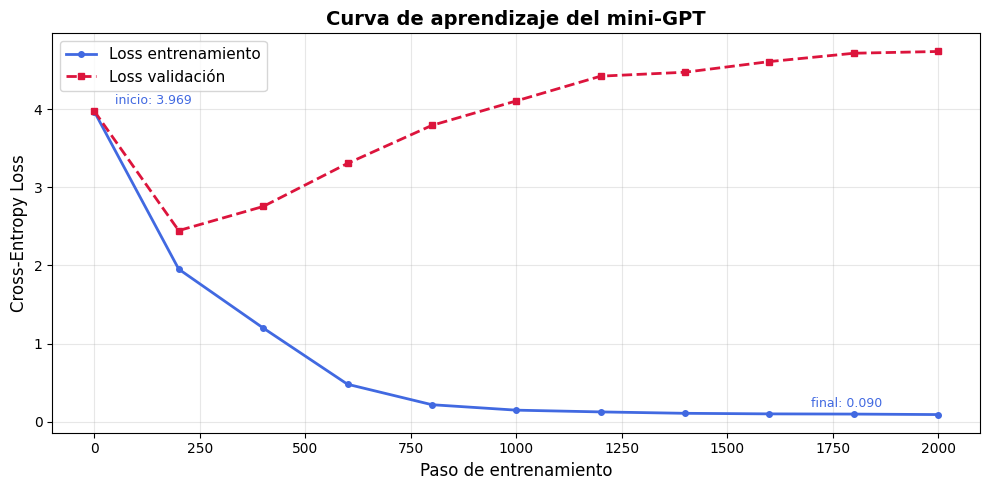

📉 El modelo redujo su pérdida en 3.879 puntos
   Inicio : 3.9690
   Final  : 0.0901


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(historial_pasos, historial_loss_train,
        label="Loss entrenamiento", color="royalblue",  linewidth=2, marker="o", markersize=4)
ax.plot(historial_pasos, historial_loss_val,
        label="Loss validación",    color="crimson",    linewidth=2, marker="s", markersize=4,
        linestyle="--")

ax.set_xlabel("Paso de entrenamiento", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss",    fontsize=12)
ax.set_title("Curva de aprendizaje del mini-GPT", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Anotar valores inicial y final
ax.annotate(f"inicio: {historial_loss_train[0]:.3f}",
            xy=(historial_pasos[0], historial_loss_train[0]),
            xytext=(historial_pasos[0] + 50, historial_loss_train[0] + 0.1),
            fontsize=9, color="royalblue")
ax.annotate(f"final: {historial_loss_train[-1]:.3f}",
            xy=(historial_pasos[-1], historial_loss_train[-1]),
            xytext=(historial_pasos[-1] - 300, historial_loss_train[-1] + 0.1),
            fontsize=9, color="royalblue")

plt.tight_layout()
plt.show()

mejora = historial_loss_train[0] - historial_loss_train[-1]
print(f"📉 El modelo redujo su pérdida en {mejora:.3f} puntos")
print(f"   Inicio : {historial_loss_train[0]:.4f}")
print(f"   Final  : {historial_loss_train[-1]:.4f}")

---
## 9. Generar texto con el modelo entrenado

¡Llegó el momento de ver qué aprendió el modelo!  
Usaremos la función `generar()` que implementamos antes.

### ¿Cómo funciona la generación?

La generación es **autorregresiva**: el modelo predice un token, ese token se agrega al contexto, y entonces predice el siguiente, y así sucesivamente:

```
"La inteli" → predice "g" → "La intelig"
"La intelig" → predice "e" → "La intelige"
"La intelige" → predice "n" → "La intligen"
...
```

### El parámetro `temperatura`

- **temp < 1**: más conservador, texto más coherente pero repetitivo
- **temp = 1**: distribución original del modelo
- **temp > 1**: más aleatorio, texto más variado pero puede volverse incoherente

In [14]:
def generar_texto(
    modelo,
    texto_inicio: str = "La inteligencia",
    n_tokens: int     = 200,
    temperatura: float = 0.8
) -> str:
    """
    Helper que convierte texto inicial → tokens → genera → decodifica.
    """
    modelo.eval()

    # Codificar el texto de inicio
    tokens_inicio = torch.tensor(
        encode(texto_inicio),
        dtype=torch.long,
        device=device
    ).unsqueeze(0)  # shape (1, T)

    # Generar tokens nuevos
    tokens_generados = modelo.generar(
        tokens_inicio,
        max_nuevos_tokens = n_tokens,
        temperatura       = temperatura
    )

    # Decodificar todo el texto resultante
    texto_generado = decode(tokens_generados[0].tolist())
    return texto_generado


# ─── Probar con diferentes temperaturas ──────────────────────────────────────
print("🎨 Generación de texto con diferentes temperaturas\n")

configs_temp = [
    {"temperatura": 0.5, "label": "Conservador (temp=0.5)"},
    {"temperatura": 1.0, "label": "Neutral    (temp=1.0)"},
    {"temperatura": 1.4, "label": "Creativo   (temp=1.4)"},
]

for cfg in configs_temp:
    texto = generar_texto(
        modelo,
        texto_inicio = "La",
        n_tokens     = 150,
        temperatura  = cfg["temperatura"]
    )
    print(f"🌡️  {cfg['label']}:")
    print(f"{'─'*60}")
    print(texto)
    print()

🎨 Generación de texto con diferentes temperaturas

🌡️  Conservador (temp=0.5):
────────────────────────────────────────────────────────────
La inteligencia artificial que permite a los sistemas aprender y mejorar a partir de la experiencia sin ser programados explícitamente. El aprendizaje a

🌡️  Neutral    (temp=1.0):
────────────────────────────────────────────────────────────
Las se incluyen el reconocimiento de voz, la comprensión del lenguaje natural, el aprendizaje y la resolución de problemas.

El aprendizaje automático e

🌡️  Creativo   (temp=1.4):
────────────────────────────────────────────────────────────
LaMA. Entre estas tareas se incluyen el reconocimiento de voz, la comprensión del lenguaje consiste en presentarle millones de ejemplos de texto y mejor



---
## 10. Perplexity: midiendo la calidad del modelo

La **perplexity** (perplejidad) es la métrica estándar para evaluar modelos de lenguaje.

### ¿Qué mide la perplexity?

Intuitivamente: **cuántas opciones igualmente probables tiene el modelo en cada posición**.

$$\text{PPL} = e^{\mathcal{L}} = e^{\text{cross-entropy loss}}$$

| Perplexity | Interpretación |
|---|---|
| PPL = 1 | Predice perfectamente (imposible en la práctica) |
| PPL = vocab_size | Sin aprender nada (distribución uniforme) |
| PPL = 10 | En cada posición elige entre ~10 tokens igualmente probables |
| PPL = 100 | Aún bastante incierto |

_
> Para referencia: **GPT-4** tiene perplexity < 5 en muchos benchmarks.
> Nuestro mini-modelo con dataset pequeño tendrá valores mucho más altos — y está bien.

In [15]:
@torch.no_grad()
def calcular_perplexity(split: str = "val", n_batches: int = 50) -> float:
    """
    Calcula la perplexity promedio en el conjunto especificado.
    
    PPL = exp(cross_entropy_loss)
    
    Un valor menor indica un modelo mejor.
    PPL == vocab_size sería un modelo que no aprendió nada (distribución uniforme).
    """
    modelo.eval()
    losses = []

    for _ in range(n_batches):
        xb, yb = get_batch(split)
        _, loss = modelo(xb, yb)
        losses.append(loss.item())

    loss_promedio = sum(losses) / len(losses)
    ppl = math.exp(loss_promedio)  # PPL = e^loss
    return ppl


ppl_train = calcular_perplexity("train")
ppl_val   = calcular_perplexity("val")

# Un modelo que no aprendió nada tendría PPL == vocab_size
ppl_baseline = vocab_size  

mejora_relativa = (ppl_baseline - ppl_val) / ppl_baseline * 100

print(f"📊 Perplexity del modelo:")
print(f"   Entrenamiento : {ppl_train:.2f}")
print(f"   Validación    : {ppl_val:.2f}")
print()
print(f"📏 Baseline (sin aprender): {ppl_baseline:.2f}")
print(f"📈 Mejora relativa        : {mejora_relativa:.1f}% mejor que baseline")
print()
print(f"Interpretación:")
print(f"  Un modelo perfecto tendría PPL=1.")
print(f"  Un modelo sin entrenamiento tendría PPL={ppl_baseline} (= vocab_size).")
print(f"  Nuestro modelo tiene PPL valdación={ppl_val:.1f}.")

📊 Perplexity del modelo:
   Entrenamiento : 1.10
   Validación    : 117.03

📏 Baseline (sin aprender): 46.00
📈 Mejora relativa        : -154.4% mejor que baseline

Interpretación:
  Un modelo perfecto tendría PPL=1.
  Un modelo sin entrenamiento tendría PPL=46 (= vocab_size).
  Nuestro modelo tiene PPL valdación=117.0.


---
## 11. Experimentos: ¿cómo mejorar el modelo?

Ahora que entendés la base, podés experimentar con estos cambios para ver cómo impactan en la calidad.

### Experimento A: más datos

El factor más importante en LLMs. Reemplazá `TEXTO` con un archivo más grande:

```python
# Cargar cualquier archivo de texto
with open("mi_libro.txt", "r", encoding="utf-8") as f:
    TEXTO = f.read()
```

### Experimento B: más capacidad del modelo

Subir `D_MODELO`, `N_HEADS`, `N_CAPAS`. Tabla de referencia:

| Config | Params | Entrenamiento |
|---|---|---|
| D=64, H=2, L=2 | ~50K | <1 min CPU |
| D=128, H=4, L=4 | ~500K | ~5 min CPU |
| D=256, H=8, L=6 | ~3M | ~30 min CPU |
| D=512, H=8, L=8 | ~12M | GPU recomendada |

### Experimento C: ajustar el learning rate

```python
# Con un scheduler que reduce el LR con cada paso
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=N_PASOS)
# Agregar scheduler.step() al final de cada paso de entrenamiento
```

### Experimento D: tokenización BPE (subpalabras)

```python
# Tokenizador de Hugging Face (BPE, más eficiente que character-level)
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokens = tokenizer.encode(TEXTO)
# vocab_size = tokenizer.vocab_size  # ~50,000
```

### Experimento E: guardar y cargar el modelo

```python
# Guardar
torch.save(modelo.state_dict(), "mini_gpt.pth")

# Cargar
modelo_cargado = MiniGPT().to(device)
modelo_cargado.load_state_dict(torch.load("mini_gpt.pth", map_location=device))
```

In [16]:
# ─── Scheduler de learning rate coseno (Experimento C) ────────────────────────
# Descomentar para usar en el próximo entrenamiento

# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizador,
#     T_max    = N_PASOS,
#     eta_min  = 1e-6
# )
# # Al final del loop agregar: scheduler.step()

# ─── Guardar el modelo entrenado ─────────────────────────────────────────────
ruta_guardado = "mini_gpt_entrenado.pth"
torch.save({
    "model_state_dict": modelo.state_dict(),
    "config": {
        "d_modelo" : D_MODELO,
        "n_heads"  : N_HEADS,
        "n_capas"  : N_CAPAS,
        "contexto" : CONTEXTO,
        "vocab_size": vocab_size,
    },
    "vocabulario"    : vocabulario,
    "loss_final_train": historial_loss_train[-1],
    "loss_final_val"  : historial_loss_val[-1],
}, ruta_guardado)

import os
tamaño_kb = os.path.getsize(ruta_guardado) / 1024
print(f"💾 Modelo guardado en: {ruta_guardado}")
print(f"   Tamaño: {tamaño_kb:.1f} KB ({n_params:,} parámetros)")

# ─── Cargar el modelo ─────────────────────────────────────────────────────────
print(f"\n⏳ Probando carga del modelo guardado...")
checkpoint = torch.load(ruta_guardado, map_location=device, weights_only=False)

modelo_cargado = MiniGPT().to(device)
modelo_cargado.load_state_dict(checkpoint["model_state_dict"])
modelo_cargado.eval()

print(f"✅ Modelo cargado correctamente")
print(f"   Configuración: D={checkpoint['config']['d_modelo']}, "
      f"H={checkpoint['config']['n_heads']}, "
      f"L={checkpoint['config']['n_capas']}")

# Probar generación con el modelo cargado
texto_prueba = generar_texto(modelo_cargado, "El aprendizaje", n_tokens=100)
print(f"\n✍️  Generación de prueba:")
print(f"{texto_prueba}")

💾 Modelo guardado en: mini_gpt_entrenado.pth
   Tamaño: 3469.3 KB (811,822 parámetros)

⏳ Probando carga del modelo guardado...
✅ Modelo cargado correctamente
   Configuración: D=128, H=4, L=4

✍️  Generación de prueba:
El aprendizaje automático es un subconjunto de la inteligencia artificial que permite a los sistemas aprender y me


---
## 12. Conclusiones y próximos pasos

### Lo que construiste en este notebook

✅ **Tokenizador** character-level: texto ↔ secuencia de enteros  
✅ **Dataset con ventana deslizante**: pares (contexto → siguiente token)  
✅ **Self-Attention causal**: el mecanismo core del Transformer  
✅ **Multi-Head Attention**: múltiples heads especializados en paralelo  
✅ **Feed-Forward Network**: procesamiento no-lineal por token  
✅ **Bloque Transformer completo** con LayerNorm y conexiones residuales  
✅ **miniGPT** ensamblado con embeddings de token y posición  
✅ **Loop de entrenamiento** con AdamW, gradient clipping y evaluación  
✅ **Curva de pérdida** train/val para diagnosticar el aprendizaje  
✅ **Generación de texto** autorregresiva con temperatura  
✅ **Perplexity** como métrica estándar de calidad  
✅ **Guardar/cargar** checkpoints del modelo  

---

### La diferencia entre nuestro modelo y GPT-4

| Característica | nuestro mini-GPT | GPT-4 (estimado) |
|---|---|---|
| Parámetros | ~500K | ~1 Billón |
| Tokens entrenamiento | ~3,000 | ~13 Trillones |
| Contexto | 64 tokens | 128K tokens |
| Capas | 4 | ~120 |
| D_modelo | 128 | ~12,288 |
| Tiempo entrenamiento | minutos (CPU) | meses (miles de GPUs) |

La **arquitectura** es la misma — la diferencia es **escala**.

---

### Próximos pasos sugeridos

| Paso | Descripción |
|---|---|
| 📦 Dataset real | Descargar [TinyShakespeare](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt) (~1MB) |
| 🔤 BPE tokenizer | Usar `tiktoken` o `transformers` para tokenización subword |
| 🎓 Fine-tuning | Partir de un modelo pre-entrenado (GPT-2, Llama) y afinar con tus datos |
| 💬 RLHF / SFT | Aprende cómo se alinean los modelos para seguir instrucciones |
| 📚 El paper | Leer ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) (2017) |
| 🎥 Video | Ver ["Let's build GPT" by Andrej Karpathy](https://youtu.be/kCc8FmEb1nY) |

---

> 🎯 **Tarea:** Modificá el `TEXTO` con un archivo de texto propio (un libro, noticias,  
> código fuente) y reentrenar. Observá cómo cambia el texto generado.